# 🎨 AI Stylist — Bedrock + API Gateway Setup

**What this notebook does (in order):**
1. ✅ Install packages
2. ✅ You enter your existing resource names (bucket, Lambda, role)
3. ✅ Test Bedrock → Claude 3 Sonnet (text)
4. ✅ Test Bedrock → Nova Canvas (image generation)
5. ✅ Verify your Lambda function is live
6. ✅ Create API Gateway REST API automatically
7. ✅ Add `/recommend` resource + POST method
8. ✅ Enable CORS automatically
9. ✅ Deploy the API and print your Invoke URL
10. ✅ Full end-to-end test

**Prerequisites (already done by you before running this):**
- S3 bucket created ✅
- IAM role for Lambda created ✅
- Lambda function created ✅

---
> ⚠️ **Run cells ONE AT A TIME, top to bottom.** Do not skip any cell.

## Cell 1 — Install Required Packages

In [1]:
# ─── CELL 1: Install packages ───────────────────────────────────────────────
# Run this first. Ignore any red dependency warning messages — they are safe.

print("📦 Installing packages...")
!pip install boto3 pillow requests --quiet
print("✅ Packages ready!")

📦 Installing packages...
✅ Packages ready!


## Cell 2 — ⚙️ YOUR CONFIGURATION (Edit This Cell Before Running)

> **This is the only cell you need to edit.**  
> Fill in the names of the resources you already created in the AWS Console.

In [2]:
# ─── CELL 2: YOUR CONFIG — Replace all values below ─────────────────────────
#
# ⚠️  Fill in YOUR actual names. These must match exactly what you created
#     in the AWS Console (case-sensitive, no extra spaces).

# ── 1. The S3 bucket you created manually ───────────────────────────────────
S3_BUCKET_NAME = "YOUR-BUCKET-NAME"          # e.g. "my-ai-stylist-bucket-2026"

# ── 2. Your Lambda function name ────────────────────────────────────────────
LAMBDA_FUNCTION_NAME = "YOUR-LAMBDA-NAME"    # e.g. "my-ai-stylist-generator"

# ── 3. AWS Region (keep us-east-1 unless you set everything up in another region)
AWS_REGION = "us-east-1"

# ── 4. Bedrock Model IDs (copy from Bedrock → Model catalog in AWS Console) ─
CLAUDE_MODEL_ID = "anthropic.claude-3-sonnet-20240229-v1:0"
NOVA_MODEL_ID   = "amazon.nova-canvas-v1:0"

# ── 5. API Gateway settings ──────────────────────────────────────────────────
API_NAME        = "ai-stylist-api"           # Name for your new API Gateway
API_STAGE       = "prod"                     # Deployment stage name
API_RESOURCE    = "recommend"                # The URL path: /recommend

# ─────────────────────────────────────────────────────────────────────────────
print("✅ Config loaded:")
print(f"   S3 Bucket    : {S3_BUCKET_NAME}")
print(f"   Lambda       : {LAMBDA_FUNCTION_NAME}")
print(f"   Region       : {AWS_REGION}")
print(f"   Claude Model : {CLAUDE_MODEL_ID}")
print(f"   Nova Model   : {NOVA_MODEL_ID}")
print(f"   API Name     : {API_NAME}")

✅ Config loaded:
   S3 Bucket    : YOUR-BUCKET-NAME
   Lambda       : YOUR-LAMBDA-NAME
   Region       : us-east-1
   Claude Model : anthropic.claude-3-sonnet-20240229-v1:0
   Nova Model   : amazon.nova-canvas-v1:0
   API Name     : ai-stylist-api


In [3]:
# ─── CELL 2: YOUR CONFIG — Replace all values below ─────────────────────────
#
# ⚠️  Fill in YOUR actual names. These must match exactly what you created
#     in the AWS Console (case-sensitive, no extra spaces).

# ── 1. The S3 bucket you created manually ───────────────────────────────────
S3_BUCKET_NAME = "ai-stylist-bucket-2026"          # e.g. "my-ai-stylist-bucket-2026"

# ── 2. Your Lambda function name ────────────────────────────────────────────
LAMBDA_FUNCTION_NAME = "ai-stylist-generator"    # e.g. "my-ai-stylist-generator"

# ── 3. AWS Region (keep us-east-1 unless you set everything up in another region)
AWS_REGION = "us-east-1"

# ── 4. Bedrock Model IDs (copy from Bedrock → Model catalog in AWS Console) ─
CLAUDE_MODEL_ID = "anthropic.claude-3-sonnet-20240229-v1:0"
NOVA_MODEL_ID   = "amazon.nova-canvas-v1:0"

# ── 5. API Gateway settings ──────────────────────────────────────────────────
API_NAME        = "ai-stylist-api"           # Name for your new API Gateway
API_STAGE       = "prod"                     # Deployment stage name
API_RESOURCE    = "recommend"                # The URL path: /recommend

# ─────────────────────────────────────────────────────────────────────────────
print("✅ Config loaded:")
print(f"   S3 Bucket    : {S3_BUCKET_NAME}")
print(f"   Lambda       : {LAMBDA_FUNCTION_NAME}")
print(f"   Region       : {AWS_REGION}")
print(f"   Claude Model : {CLAUDE_MODEL_ID}")
print(f"   Nova Model   : {NOVA_MODEL_ID}")
print(f"   API Name     : {API_NAME}")

✅ Config loaded:
   S3 Bucket    : ai-stylist-bucket-2026
   Lambda       : ai-stylist-generator
   Region       : us-east-1
   Claude Model : anthropic.claude-3-sonnet-20240229-v1:0
   Nova Model   : amazon.nova-canvas-v1:0
   API Name     : ai-stylist-api


## Cell 3 — Import Libraries & Create AWS Clients

In [4]:
# ─── CELL 3: Imports & AWS clients ──────────────────────────────────────────

import boto3
import json
import base64
import io
import time
from PIL import Image
from IPython import display as ipython_display

# Create one client for each AWS service we need
bedrock_client  = boto3.client('bedrock-runtime',  region_name=AWS_REGION)
lambda_client   = boto3.client('lambda',           region_name=AWS_REGION)
apigw_client    = boto3.client('apigateway',       region_name=AWS_REGION)
s3_client       = boto3.client('s3',               region_name=AWS_REGION)
sts_client      = boto3.client('sts',              region_name=AWS_REGION)

# Get our AWS account ID (needed when giving API Gateway permission to call Lambda)
ACCOUNT_ID = sts_client.get_caller_identity()['Account']

print("✅ AWS clients created successfully")
print(f"   Account ID: {ACCOUNT_ID}")
print(f"   Region    : {AWS_REGION}")

✅ AWS clients created successfully
   Account ID: 634602958025
   Region    : us-east-1


## Cell 4 — Test Bedrock: Claude 3 Sonnet (Text Generation)

In [5]:
# ─── CELL 4: Test Claude 3 Sonnet via Bedrock ───────────────────────────────
#
# This sends a quick outfit request to Claude to verify your Bedrock
# access is working correctly.

print("🤖 Testing Claude 3 Sonnet...")
print("-" * 50)

test_prompt = """
You are a fashion stylist. Give 2 brief outfit ideas for a Business Casual summer occasion.
Return ONLY valid JSON (no markdown):
[{"name": "...", "description": "..."}]
"""

try:
    response = bedrock_client.invoke_model(
        modelId=CLAUDE_MODEL_ID,
        body=json.dumps({
            "anthropic_version": "bedrock-2023-05-31",
            "max_tokens": 500,
            "messages": [{"role": "user", "content": test_prompt}]
        }),
        contentType="application/json",
        accept="application/json"
    )

    result = json.loads(response['body'].read())
    text   = result['content'][0]['text']

    print("✅ Claude responded successfully!")
    print()
    print("Raw response from Claude:")
    print(text)

except Exception as e:
    print(f"❌ Claude test FAILED: {e}")
    print()
    print("Common fixes:")
    print("  → Check that you have Bedrock model access in the AWS Console")
    print("  → Verify CLAUDE_MODEL_ID is correct in Cell 2")
    print("  → Make sure your IAM role has bedrock:InvokeModel permission")

🤖 Testing Claude 3 Sonnet...
--------------------------------------------------
✅ Claude responded successfully!

Raw response from Claude:
[{"name": "Lightweight Blazer and Trousers", "description": "A lightweight blazer in a neutral color like beige or light gray paired with tailored trousers or chino pants and a crisp button-down shirt or blouse. Accessorize with loafers or ballet flats and a simple necklace."}, {"name": "Sheath Dress and Cardigan", "description": "A knee-length sheath dress in a solid color or subtle print, paired with a lightweight cardigan in a complementary shade. Add closed-toe pumps or sandals and a structured handbag."}]


## Cell 5 — Test Bedrock: Nova Canvas (Image Generation)

🎨 Testing Nova Canvas image generation...
--------------------------------------------------
✅ Nova Canvas responded successfully!
   Image size: 512x512 px

🖼️  Generated test image:


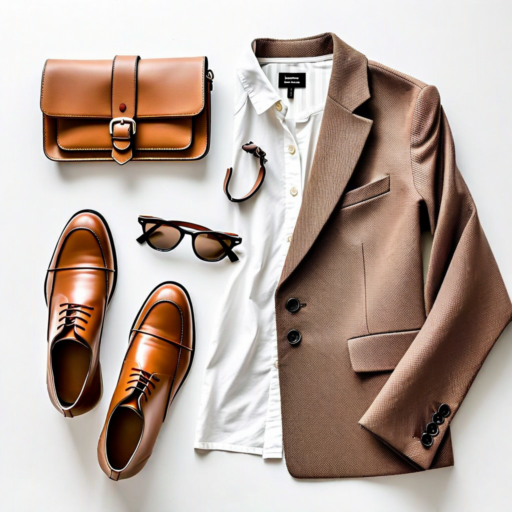

In [6]:
# ─── CELL 5: Test Nova Canvas image generation ──────────────────────────────
#
# Generates a single test image and displays it in the notebook.
# This confirms Nova Canvas is accessible before we build the full pipeline.

print("🎨 Testing Nova Canvas image generation...")
print("-" * 50)

try:
    nova_response = bedrock_client.invoke_model(
        modelId=NOVA_MODEL_ID,
        body=json.dumps({
            "taskType": "TEXT_IMAGE",
            "textToImageParams": {
                "text": "A professional business casual outfit, flat lay on white background, fashion photography",
                "negativeText": "person, face, low quality, blurry"
            },
            "imageGenerationConfig": {
                "numberOfImages": 1,
                "height": 512,
                "width": 512,
                "cfgScale": 8.5,
                "seed": 42
            }
        }),
        contentType="application/json",
        accept="application/json"
    )

    nova_body   = json.loads(nova_response['body'].read())
    image_bytes = base64.b64decode(nova_body['images'][0])
    image       = Image.open(io.BytesIO(image_bytes))

    print("✅ Nova Canvas responded successfully!")
    print(f"   Image size: {image.size[0]}x{image.size[1]} px")
    print()
    print("🖼️  Generated test image:")
    ipython_display.display(image)

except Exception as e:
    print(f"❌ Nova Canvas test FAILED: {e}")
    print()
    print("Common fixes:")
    print("  → Check that Nova Canvas has Access Granted in Bedrock Model catalog")
    print("  → Verify NOVA_MODEL_ID is correct in Cell 2")

## Cell 6 — Verify Your Lambda Function Exists

In [7]:
# ─── CELL 6: Verify Lambda exists ───────────────────────────────────────────
#
# Checks that the Lambda function you created in the Console is reachable.
# Also retrieves its ARN which we need when creating the API Gateway integration.

print("⚡ Verifying Lambda function...")
print("-" * 50)

try:
    fn = lambda_client.get_function(FunctionName=LAMBDA_FUNCTION_NAME)
    config = fn['Configuration']

    LAMBDA_ARN = config['FunctionArn']

    print("✅ Lambda function found!")
    print(f"   Name    : {config['FunctionName']}")
    print(f"   Runtime : {config['Runtime']}")
    print(f"   Memory  : {config['MemorySize']} MB")
    print(f"   Timeout : {config['Timeout']} seconds")
    print(f"   ARN     : {LAMBDA_ARN}")

    # Warn if timeout is too low (image generation needs at least 60s)
    if config['Timeout'] < 60:
        print()
        print("⚠️  WARNING: Timeout is less than 60 seconds!")
        print("   Image generation can take 30-60 seconds.")
        print("   Go to Lambda → Configuration → General configuration → set Timeout to 3 min")
    else:
        print(f"   Timeout is OK ✅")

except lambda_client.exceptions.ResourceNotFoundException:
    print(f"❌ Lambda function '{LAMBDA_FUNCTION_NAME}' not found!")
    print("   Check the LAMBDA_FUNCTION_NAME in Cell 2 matches exactly.")
    LAMBDA_ARN = None

except Exception as e:
    print(f"❌ Error: {e}")
    LAMBDA_ARN = None

⚡ Verifying Lambda function...
--------------------------------------------------
✅ Lambda function found!
   Name    : ai-stylist-generator
   Runtime : python3.14
   Memory  : 512 MB
   Timeout : 180 seconds
   ARN     : arn:aws:lambda:us-east-1:634602958025:function:ai-stylist-generator
   Timeout is OK ✅


## Cell 7 — Create API Gateway REST API

> This creates a brand new REST API in API Gateway. It will NOT overwrite any existing API.

In [8]:
# ─── CELL 7: Create the REST API ────────────────────────────────────────────
#
# Creates a new REST API in API Gateway.
# If an API with the same name already exists, we fetch it instead of
# creating a duplicate.

print("🌐 Creating API Gateway REST API...")
print("-" * 50)

if LAMBDA_ARN is None:
    print("❌ Cannot continue — Lambda ARN not set. Fix Cell 6 first.")
else:
    try:
        # Check if an API with this name already exists
        existing_apis = apigw_client.get_rest_apis()['items']
        existing = [a for a in existing_apis if a['name'] == API_NAME]

        if existing:
            api = existing[0]
            REST_API_ID   = api['id']
            ROOT_RESOURCE = apigw_client.get_resources(restApiId=REST_API_ID)['items']
            ROOT_ID       = [r for r in ROOT_RESOURCE if r['path'] == '/'][0]['id']
            print(f"ℹ️  API '{API_NAME}' already exists — using it.")
        else:
            # Create a fresh REST API
            api = apigw_client.create_rest_api(
                name=API_NAME,
                description="AI Stylist outfit recommendation API",
                endpointConfiguration={'types': ['REGIONAL']}
            )
            REST_API_ID = api['id']

            # Every REST API starts with a root resource '/'
            # We need its ID to create child resources under it
            resources = apigw_client.get_resources(restApiId=REST_API_ID)['items']
            ROOT_ID   = [r for r in resources if r['path'] == '/'][0]['id']
            print(f"✅ API created: {API_NAME}")

        print(f"   API ID      : {REST_API_ID}")
        print(f"   Root ID     : {ROOT_ID}")

    except Exception as e:
        print(f"❌ Failed to create API: {e}")
        REST_API_ID = None
        ROOT_ID     = None

🌐 Creating API Gateway REST API...
--------------------------------------------------
✅ API created: ai-stylist-api
   API ID      : 29er51l9k5
   Root ID     : wm8p31qn36


## Cell 8 — Create `/recommend` Resource + POST Method

In [9]:
# ─── CELL 8: Create /recommend resource and POST method ─────────────────────
#
# Creates the /recommend URL path and wires it to your Lambda function.
# Lambda Proxy Integration = API Gateway passes the full HTTP request
# straight to Lambda, including headers and body.

print("📡 Creating /recommend resource and POST method...")
print("-" * 50)

if REST_API_ID is None:
    print("❌ Cannot continue — REST_API_ID not set. Fix Cell 7 first.")
else:
    try:
        # ── Step 1: Create /recommend resource ──────────────────────────────
        # Check if /recommend already exists
        all_resources  = apigw_client.get_resources(restApiId=REST_API_ID)['items']
        recommend_res  = [r for r in all_resources if r.get('pathPart') == API_RESOURCE]

        if recommend_res:
            RESOURCE_ID = recommend_res[0]['id']
            print(f"ℹ️  Resource '/{API_RESOURCE}' already exists — using it.")
        else:
            resource = apigw_client.create_resource(
                restApiId=REST_API_ID,
                parentId=ROOT_ID,
                pathPart=API_RESOURCE        # creates the /recommend path
            )
            RESOURCE_ID = resource['id']
            print(f"✅ Resource created: /{API_RESOURCE}")

        # ── Step 2: Create POST method on /recommend ─────────────────────────
        try:
            apigw_client.put_method(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='POST',
                authorizationType='NONE'    # public endpoint — no auth required
            )
            print("✅ POST method created")
        except apigw_client.exceptions.ConflictException:
            print("ℹ️  POST method already exists — skipping.")

        # ── Step 3: Link POST method → Lambda (Proxy Integration) ───────────
        LAMBDA_INVOKE_URI = (
            f"arn:aws:apigateway:{AWS_REGION}:lambda:"
            f"path/2015-03-31/functions/{LAMBDA_ARN}/invocations"
        )

        try:
            apigw_client.put_integration(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='POST',
                type='AWS_PROXY',               # Lambda Proxy Integration
                integrationHttpMethod='POST',   # must be POST when calling Lambda
                uri=LAMBDA_INVOKE_URI
            )
            print("✅ Lambda integration linked")
        except apigw_client.exceptions.ConflictException:
            print("ℹ️  Integration already exists — skipping.")

        print(f"   Resource ID : {RESOURCE_ID}")
        print(f"   Lambda URI  : {LAMBDA_INVOKE_URI[:70]}...")

    except Exception as e:
        print(f"❌ Failed: {e}")
        RESOURCE_ID = None

📡 Creating /recommend resource and POST method...
--------------------------------------------------
✅ Resource created: /recommend
✅ POST method created
✅ Lambda integration linked
   Resource ID : 7tw4tw
   Lambda URI  : arn:aws:apigateway:us-east-1:lambda:path/2015-03-31/functions/arn:aws:...


## Cell 9 — Enable CORS on `/recommend`

> CORS (Cross-Origin Resource Sharing) is required so a web browser on a different domain can call this API.

In [10]:
# ─── CELL 9: Enable CORS ────────────────────────────────────────────────────
#
# CORS is enabled by:
#   1. Adding an OPTIONS method that returns the correct Allow-* headers
#      (browsers send an OPTIONS 'preflight' request before the real POST)
#   2. Adding the same headers to the POST method response
#
# The actual CORS headers are also returned by your Lambda function code.
# Both are needed for full CORS support.

print("🔓 Enabling CORS on /recommend...")
print("-" * 50)

if RESOURCE_ID is None:
    print("❌ Cannot continue — RESOURCE_ID not set. Fix Cell 8 first.")
else:
    try:
        # ── Step 1: Create OPTIONS method (preflight handler) ────────────────
        try:
            apigw_client.put_method(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='OPTIONS',
                authorizationType='NONE'
            )
        except apigw_client.exceptions.ConflictException:
            pass  # already exists

        # ── Step 2: OPTIONS integration — MOCK (returns headers, no Lambda) ──
        try:
            apigw_client.put_integration(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='OPTIONS',
                type='MOCK',
                requestTemplates={'application/json': '{"statusCode": 200}'}
            )
        except apigw_client.exceptions.ConflictException:
            pass

        # ── Step 3: Define what the OPTIONS response looks like ──────────────
        CORS_HEADERS = {
            'method.response.header.Access-Control-Allow-Headers': False,
            'method.response.header.Access-Control-Allow-Methods': False,
            'method.response.header.Access-Control-Allow-Origin':  False
        }

        try:
            apigw_client.put_method_response(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='OPTIONS',
                statusCode='200',
                responseParameters=CORS_HEADERS
            )
        except apigw_client.exceptions.ConflictException:
            pass

        # ── Step 4: Set the actual CORS header values in the integration response
        CORS_VALUES = {
            'method.response.header.Access-Control-Allow-Headers':  "'Content-Type,X-Amz-Date,Authorization,X-Api-Key'",
            'method.response.header.Access-Control-Allow-Methods':  "'POST,OPTIONS'",
            'method.response.header.Access-Control-Allow-Origin':   "'*'"
        }

        try:
            apigw_client.put_integration_response(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='OPTIONS',
                statusCode='200',
                responseParameters=CORS_VALUES,
                responseTemplates={'application/json': ''}
            )
        except apigw_client.exceptions.ConflictException:
            pass

        # ── Step 5: Add CORS headers to POST method response too ─────────────
        try:
            apigw_client.put_method_response(
                restApiId=REST_API_ID,
                resourceId=RESOURCE_ID,
                httpMethod='POST',
                statusCode='200',
                responseParameters=CORS_HEADERS
            )
        except apigw_client.exceptions.ConflictException:
            pass

        print("✅ CORS enabled successfully!")
        print("   OPTIONS method   : created (handles browser preflight)")
        print("   Allow-Origin     : * (any domain can call this API)")
        print("   Allow-Methods    : POST, OPTIONS")
        print("   Allow-Headers    : Content-Type, Authorization, etc.")

    except Exception as e:
        print(f"❌ CORS setup failed: {e}")

🔓 Enabling CORS on /recommend...
--------------------------------------------------
✅ CORS enabled successfully!
   OPTIONS method   : created (handles browser preflight)
   Allow-Origin     : * (any domain can call this API)
   Allow-Methods    : POST, OPTIONS
   Allow-Headers    : Content-Type, Authorization, etc.


## Cell 10 — Give API Gateway Permission to Call Lambda

In [11]:
# ─── CELL 10: Grant API Gateway permission to invoke Lambda ─────────────────
#
# API Gateway needs explicit permission to call your Lambda function.
# We add a resource-based policy to Lambda that allows API Gateway to invoke it.
#
# Without this step the API Gateway will return a 500 error even though
# everything else is configured correctly.

print("🔑 Granting API Gateway permission to call Lambda...")
print("-" * 50)

if REST_API_ID is None:
    print("❌ Cannot continue — REST_API_ID not set. Fix Cell 7 first.")
else:
    # Build the source ARN — this says 'only this specific API Gateway can invoke Lambda'
    SOURCE_ARN = (
        f"arn:aws:execute-api:{AWS_REGION}:{ACCOUNT_ID}:"
        f"{REST_API_ID}/*"
    )

    try:
        lambda_client.add_permission(
            FunctionName=LAMBDA_FUNCTION_NAME,
            StatementId="APIGatewayInvokePermission",  # unique ID for this permission
            Action="lambda:InvokeFunction",
            Principal="apigateway.amazonaws.com",
            SourceArn=SOURCE_ARN
        )
        print("✅ Permission granted!")
        print(f"   Source ARN: {SOURCE_ARN}")

    except lambda_client.exceptions.ResourceConflictException:
        # Permission already exists — this is fine
        print("ℹ️  Permission already exists — no action needed.")

    except Exception as e:
        print(f"❌ Failed to add permission: {e}")

🔑 Granting API Gateway permission to call Lambda...
--------------------------------------------------
✅ Permission granted!
   Source ARN: arn:aws:execute-api:us-east-1:634602958025:29er51l9k5/*


## Cell 11 — Deploy the API and Get Your Invoke URL

In [12]:
# ─── CELL 11: Deploy API and print Invoke URL ────────────────────────────────
#
# API Gateway changes don't go live until you 'deploy' them to a stage.
# A stage is just a named version of your API (we use 'prod').
# After deployment, you get a public HTTPS URL you can call from anywhere.

print("🚀 Deploying API to stage: " + API_STAGE)
print("-" * 50)

if REST_API_ID is None:
    print("❌ Cannot continue — REST_API_ID not set.")
else:
    try:
        deployment = apigw_client.create_deployment(
            restApiId=REST_API_ID,
            stageName=API_STAGE,
            description="AI Stylist production deployment"
        )

        INVOKE_URL    = f"https://{REST_API_ID}.execute-api.{AWS_REGION}.amazonaws.com/{API_STAGE}"
        RECOMMEND_URL = f"{INVOKE_URL}/{API_RESOURCE}"

        print("✅ API deployed successfully!")
        print()
        print("=" * 60)
        print("📋 YOUR API DETAILS")
        print("=" * 60)
        print(f"  API Name     : {API_NAME}")
        print(f"  API ID       : {REST_API_ID}")
        print(f"  Stage        : {API_STAGE}")
        print()
        print(f"  Base URL     : {INVOKE_URL}")
        print()
        print(f"  ENDPOINT URL : {RECOMMEND_URL}")
        print("                 ^^^ THIS is what you POST requests to ^^^")
        print("=" * 60)

    except Exception as e:
        print(f"❌ Deployment failed: {e}")
        INVOKE_URL    = None
        RECOMMEND_URL = None

🚀 Deploying API to stage: prod
--------------------------------------------------
✅ API deployed successfully!

📋 YOUR API DETAILS
  API Name     : ai-stylist-api
  API ID       : 29er51l9k5
  Stage        : prod

  Base URL     : https://29er51l9k5.execute-api.us-east-1.amazonaws.com/prod

  ENDPOINT URL : https://29er51l9k5.execute-api.us-east-1.amazonaws.com/prod/recommend
                 ^^^ THIS is what you POST requests to ^^^


## Cell 12 — Full End-to-End Test

> Calls the live API endpoint and shows you the outfit descriptions + images.

🧪 Running full end-to-end test...
--------------------------------------------------
📤 Sending request to: https://29er51l9k5.execute-api.us-east-1.amazonaws.com/prod/recommend
   Payload: {
  "occasion": "Business Casual",
  "season": "Summer",
  "styles": [
    "Minimalist",
    "Classic"
  ],
  "colors": [
    "Earth Tones",
    "Navy Blue"
  ],
  "gender": "neutral",
  "custom_prompt": "office friendly and comfortable"
}

⏳ Waiting for response (image generation takes ~30-60 sec)...

📥 HTTP Status: 200
✅ Success! Got 4 outfit(s)

👗 OUTFIT 1: Earthy Minimalist Ensemble
📝 A lightweight beige linen shirt paired with tailored olive chino pants. Add a woven leather belt and slip-on muted brown loafers for a polished yet relaxed look. Top it off with a navy blue linen blazer for the office.

🖼️  Generated image:


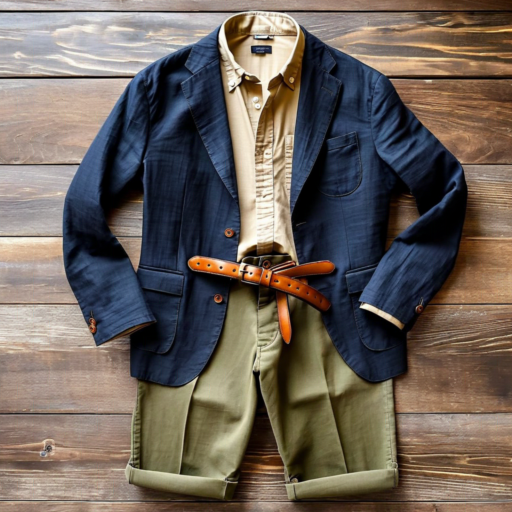

🔗 Direct URL: https://ai-stylist-bucket-2026.s3.amazonaws.com/outfits/neutral/20260228-094238/...

👗 OUTFIT 2: Navy Chic Simplicity
📝 A navy blue linen jumpsuit with wide legs and a sleeveless top. Pair it with nude leather sandals and a classic tan leather tote bag. Accessorize with a few gold bangles for a touch of elegance.

🖼️  Generated image:


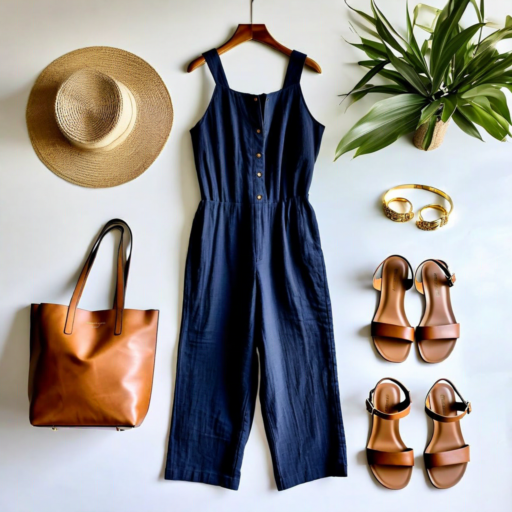

🔗 Direct URL: https://ai-stylist-bucket-2026.s3.amazonaws.com/outfits/neutral/20260228-094241/...

👗 OUTFIT 3: Earthy Tailored Look
📝 A light khaki cotton button-up shirt tucked into high-waisted taupe trousers. Add a woven brown leather belt and tan oxford shoes for a polished look. Top it off with a lightweight khaki blazer for the office.

🖼️  Generated image:


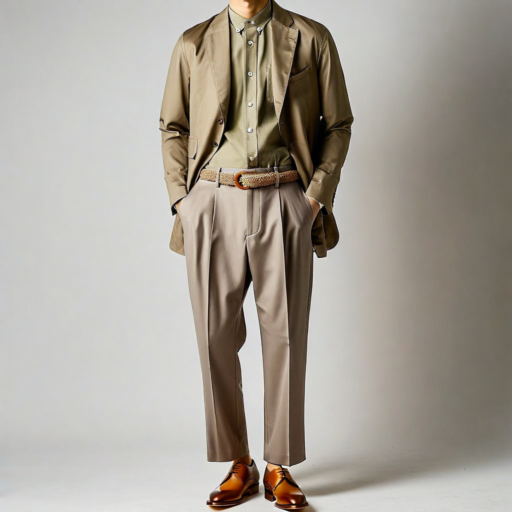

🔗 Direct URL: https://ai-stylist-bucket-2026.s3.amazonaws.com/outfits/neutral/20260228-094244/...

👗 OUTFIT 4: Classic Navy Elegance
📝 A navy blue sheath dress in a breathable cotton blend. Style it with nude pointed-toe flats and a structured navy blue tote bag. Add a gold pendant necklace for a touch of sophistication.

🖼️  Generated image:


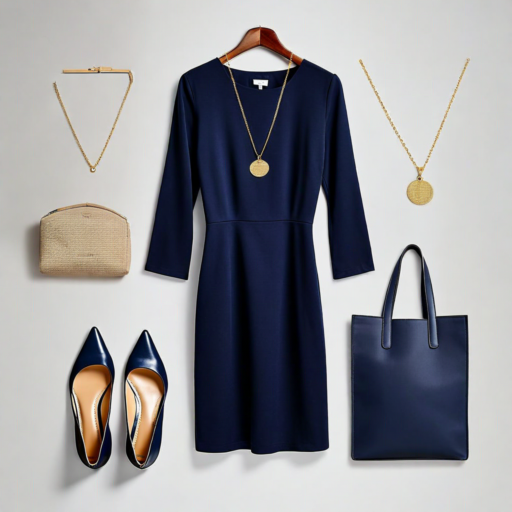

🔗 Direct URL: https://ai-stylist-bucket-2026.s3.amazonaws.com/outfits/neutral/20260228-094247/...



In [13]:
# ─── CELL 12: Full end-to-end test ──────────────────────────────────────────
#
# Sends a real HTTP POST to your deployed API and displays results.
# Image generation takes 30-60 seconds — be patient!

import requests  # HTTP library

print("🧪 Running full end-to-end test...")
print("-" * 50)

if RECOMMEND_URL is None:
    print("❌ Cannot test — RECOMMEND_URL not set. Fix Cell 11 first.")
else:
    # ── Test payload — change any of these values to try different styles ────
    test_payload = {
        "occasion":      "Business Casual",
        "season":        "Summer",
        "styles":        ["Minimalist", "Classic"],
        "colors":        ["Earth Tones", "Navy Blue"],
        "gender":        "neutral",          # options: "men", "women", "neutral"
        "custom_prompt": "office friendly and comfortable"
    }

    print(f"📤 Sending request to: {RECOMMEND_URL}")
    print(f"   Payload: {json.dumps(test_payload, indent=2)}")
    print()
    print("⏳ Waiting for response (image generation takes ~30-60 sec)...")
    print()

    try:
        response = requests.post(
            RECOMMEND_URL,
            json=test_payload,
            headers={'Content-Type': 'application/json'},
            timeout=180   # 3-minute timeout to match Lambda
        )

        print(f"📥 HTTP Status: {response.status_code}")

        if response.status_code == 200:
            data = response.json()

            if data.get('success'):
                outfits = data.get('outfits', [])
                print(f"✅ Success! Got {len(outfits)} outfit(s)")
                print()

                for i, outfit in enumerate(outfits, 1):
                    print(f"{'='*55}")
                    print(f"👗 OUTFIT {i}: {outfit.get('name', 'Untitled')}")
                    print(f"{'='*55}")
                    print(f"📝 {outfit.get('description', '')}")
                    print()

                    img_url = outfit.get('image_url')
                    if img_url:
                        try:
                            # Download and display the image inline
                            img_response = requests.get(img_url, timeout=30)
                            img = Image.open(io.BytesIO(img_response.content))
                            print(f"🖼️  Generated image:")
                            ipython_display.display(img)
                            print(f"🔗 Direct URL: {img_url[:80]}...")
                        except Exception as img_err:
                            print(f"   (Could not display image: {img_err})")
                            print(f"   Open this URL in your browser: {img_url}")
                    else:
                        err = outfit.get('error', 'Unknown')
                        print(f"   ⚠️  Image failed: {err}")
                    print()

            else:
                print(f"❌ API returned success=false")
                print(f"   Error: {data.get('error', 'Unknown')}")

        else:
            print(f"❌ HTTP {response.status_code}")
            print(f"   Body: {response.text[:500]}")
            print()
            print("Common causes:")
            print("  500 → Lambda threw an exception (check Lambda CloudWatch logs)")
            print("  403 → API Gateway permission issue (re-run Cell 10)")
            print("  504 → Lambda timed out (set timeout to 3 min in Lambda Console)")

    except requests.exceptions.Timeout:
        print("❌ Request timed out after 3 minutes")
        print("   This usually means Lambda itself timed out.")
        print("   Fix: Go to Lambda → Configuration → General → set Timeout to 3 min 0 sec")

    except Exception as e:
        print(f"❌ Request failed: {e}")

## Cell 13 — Test CORS (Optional)

> Run this to confirm the OPTIONS preflight request works correctly for browsers.

In [14]:
# ─── CELL 13: Test CORS preflight (optional) ────────────────────────────────
#
# Browsers send an OPTIONS request before a cross-origin POST.
# This cell simulates that and checks the response headers.

print("🔓 Testing CORS preflight (OPTIONS request)...")
print("-" * 50)

if RECOMMEND_URL is None:
    print("❌ RECOMMEND_URL not set. Run Cell 11 first.")
else:
    try:
        options_response = requests.options(
            RECOMMEND_URL,
            headers={
                'Origin':                         'https://your-frontend.com',
                'Access-Control-Request-Method':  'POST',
                'Access-Control-Request-Headers': 'Content-Type'
            },
            timeout=30
        )

        print(f"HTTP Status: {options_response.status_code}")
        print()
        print("CORS Headers returned:")

        cors_headers = [
            'Access-Control-Allow-Origin',
            'Access-Control-Allow-Methods',
            'Access-Control-Allow-Headers'
        ]

        all_good = True
        for h in cors_headers:
            val = options_response.headers.get(h, 'MISSING')
            status = "✅" if val != 'MISSING' else "❌"
            print(f"  {status} {h}: {val}")
            if val == 'MISSING':
                all_good = False

        print()
        if all_good:
            print("✅ CORS is configured correctly! Browsers can call this API.")
        else:
            print("⚠️  Some CORS headers are missing. Re-run Cell 9 and Cell 11.")
            print("   Note: CORS headers from Lambda code also count — check Lambda logs.")

    except Exception as e:
        print(f"❌ OPTIONS request failed: {e}")

🔓 Testing CORS preflight (OPTIONS request)...
--------------------------------------------------
HTTP Status: 200

CORS Headers returned:
  ✅ Access-Control-Allow-Origin: *
  ✅ Access-Control-Allow-Methods: POST,OPTIONS
  ✅ Access-Control-Allow-Headers: Content-Type,X-Amz-Date,Authorization,X-Api-Key

✅ CORS is configured correctly! Browsers can call this API.


## Cell 14 — Summary & Your API Details

> Run this at any time to print a summary of everything that was created.

In [15]:
# ─── CELL 14: Print summary ──────────────────────────────────────────────────

print("="*65)
print("  🎨 AI STYLIST — SETUP COMPLETE SUMMARY")
print("="*65)
print()
print("RESOURCES (existing, created by you in Console):")
print(f"  S3 Bucket       : {S3_BUCKET_NAME}")
print(f"  Lambda Function : {LAMBDA_FUNCTION_NAME}")
print()
print("BEDROCK MODELS:")
print(f"  Claude (text)   : {CLAUDE_MODEL_ID}")
print(f"  Nova (images)   : {NOVA_MODEL_ID}")
print()
print("API GATEWAY (created by this notebook):")
try:
    print(f"  API Name        : {API_NAME}")
    print(f"  API ID          : {REST_API_ID}")
    print(f"  Stage           : {API_STAGE}")
    print(f"  CORS            : Enabled (OPTIONS + POST)")
    print()
    print("YOUR ENDPOINT (POST requests go here):")
    print(f"  {RECOMMEND_URL}")
    print()
    print("SAMPLE REQUEST BODY:")
    sample = {
        "occasion": "Business Casual",
        "season": "Summer",
        "styles": ["Minimalist"],
        "colors": ["Earth Tones"],
        "gender": "neutral",
        "custom_prompt": "office friendly"
    }
    print(json.dumps(sample, indent=4))
except NameError:
    print("  (Not deployed yet — run cells 7-11 first)")
print()
print("="*65)

  🎨 AI STYLIST — SETUP COMPLETE SUMMARY

RESOURCES (existing, created by you in Console):
  S3 Bucket       : ai-stylist-bucket-2026
  Lambda Function : ai-stylist-generator

BEDROCK MODELS:
  Claude (text)   : anthropic.claude-3-sonnet-20240229-v1:0
  Nova (images)   : amazon.nova-canvas-v1:0

API GATEWAY (created by this notebook):
  API Name        : ai-stylist-api
  API ID          : 29er51l9k5
  Stage           : prod
  CORS            : Enabled (OPTIONS + POST)

YOUR ENDPOINT (POST requests go here):
  https://29er51l9k5.execute-api.us-east-1.amazonaws.com/prod/recommend

SAMPLE REQUEST BODY:
{
    "occasion": "Business Casual",
    "season": "Summer",
    "styles": [
        "Minimalist"
    ],
    "colors": [
        "Earth Tones"
    ],
    "gender": "neutral",
    "custom_prompt": "office friendly"
}



---
## 🛠 Troubleshooting Guide

| Error | Likely cause | Fix |
|-------|-------------|-----|
| `AccessDeniedException` in Cell 4/5 | Bedrock model access not granted | AWS Console → Bedrock → Model catalog → request access |
| `ResourceNotFoundException` in Cell 6 | Wrong Lambda name in Cell 2 | Double-check `LAMBDA_FUNCTION_NAME` matches exactly |
| HTTP 500 from Cell 12 | Lambda crashed | Check Lambda → Monitor → CloudWatch logs |
| HTTP 504 from Cell 12 | Lambda timed out | Lambda → Configuration → General → set Timeout to 3 min |
| HTTP 403 from Cell 12 | API Gateway can't call Lambda | Re-run Cell 10, then re-deploy with Cell 11 |
| `NoSuchBucket` error | Wrong bucket name | Check `S3_BUCKET_NAME` in Cell 2 matches your real bucket |
| Images are `null` | Nova Canvas access not granted | Bedrock → Model catalog → request Nova Canvas access |
| CORS headers missing | OPTIONS not deployed | Re-run Cells 9 and 11 |

---
**To delete the API Gateway** (cleanup):
```python
apigw_client.delete_rest_api(restApiId=REST_API_ID)
print('Deleted')
```

In [16]:
apigw_client.delete_rest_api(restApiId=REST_API_ID)
print('Deleted')

Deleted
